In [5]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

# Explainability
import shap

# Utils
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [6]:
df = pd.read_csv("Digital Marketing Campaign Conversion Prediction/digital_marketing_campaign_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [7]:
# Remove leakage + useless columns
df = df.drop(columns=['ConversionRate', 'CustomerID'])

print("Columns after cleaning:")
print(df.columns)

Columns after cleaning:
Index(['Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend',
       'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite',
       'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases',
       'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool',
       'Conversion'],
      dtype='object')


In [8]:
selected_features = [
    'Age',
    'Income',
    'AdSpend',
    'ClickThroughRate',
    'WebsiteVisits',
    'TimeOnSite',
    'PreviousPurchases',
    'Gender',
    'CampaignChannel'
]

df = df[selected_features + ['Conversion']]

In [9]:
fig = px.histogram(df, x="Conversion", title="Target Distribution")
fig.show()

print("Conversion Rate:", df['Conversion'].mean())

Conversion Rate: 0.8765


In [10]:
X = df.drop(columns=['Conversion'])
y = df['Conversion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)

Train shape: (6400, 9)


In [11]:
categorical_cols = X.select_dtypes(include='object').columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [12]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_resampled.value_counts())

After SMOTE: Conversion
1    5610
0    5610
Name: count, dtype: int64


In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 0.1408199643493761


In [14]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# XGBoost (Final Model)
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [15]:
models = {
    "Logistic": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic
              precision    recall  f1-score   support

           0       0.19      0.42      0.27       198
           1       0.90      0.76      0.82      1402

    accuracy                           0.71      1600
   macro avg       0.55      0.59      0.54      1600
weighted avg       0.81      0.71      0.75      1600

ROC-AUC: 0.6261437484689982

Random Forest
              precision    recall  f1-score   support

           0       0.25      0.28      0.26       198
           1       0.90      0.88      0.89      1402

    accuracy                           0.81      1600
   macro avg       0.57      0.58      0.58      1600
weighted avg       0.82      0.81      0.81      1600

ROC-AUC: 0.6477939163388521

XGBoost
              precision    recall  f1-score   support

           0       0.20      0.49      0.28       198
           1       0.91      0.72      0.81      1402

    accuracy                           0.69      1600
   macro avg       0.55      0.61     

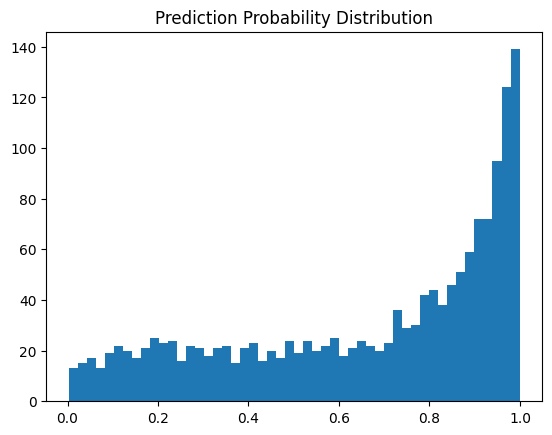

In [16]:
y_prob = xgb.predict_proba(X_test)[:,1]

plt.hist(y_prob, bins=50)
plt.title("Prediction Probability Distribution")
plt.show()

In [17]:
importance = xgb.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
10,CampaignChannel_SEO,0.152082
8,CampaignChannel_PPC,0.125933
9,CampaignChannel_Referral,0.118268
11,CampaignChannel_Social Media,0.116257
6,PreviousPurchases,0.082909
7,Gender_Male,0.076205
5,TimeOnSite,0.061301
3,ClickThroughRate,0.058996
2,AdSpend,0.056884
1,Income,0.055263


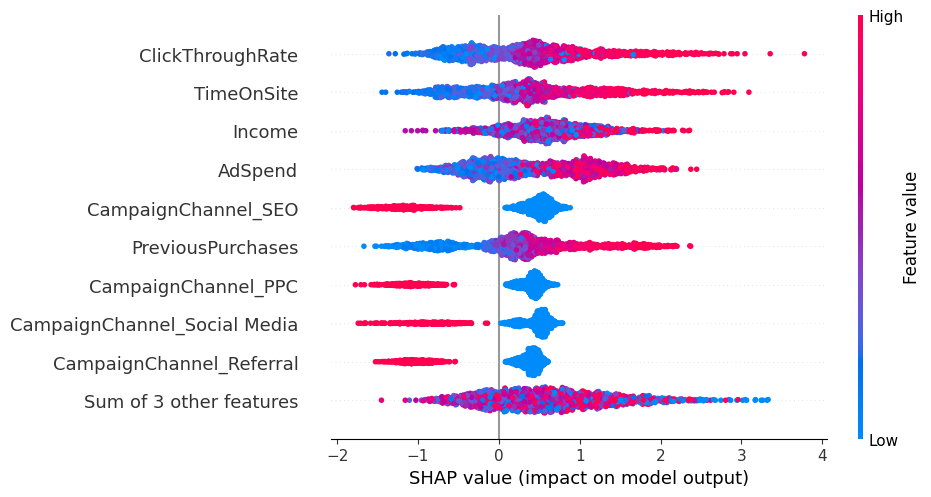

In [18]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [19]:
joblib.dump(xgb, "conversion_model.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

print("✅ Model + columns saved")

✅ Model + columns saved


## 📊 Final Insights

- XGBoost performed best
- Key drivers:
  - ClickThroughRate
  - TimeOnSite
  - PreviousPurchases

## 💰 Business Impact
- Target high probability users
- Reduce ad spend waste
- Improve ROAS

In [20]:
# 📊 FINAL POWER BI EXPORT (Independent + Robust)

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Digital Marketing Campaign Conversion Prediction/digital_marketing_campaign_dataset.csv")

# 🔥 Same cleaning as training
df = df.drop(columns=['ConversionRate', 'CustomerID'])

selected_features = [
    'Age', 'Income', 'AdSpend', 'ClickThroughRate',
    'WebsiteVisits', 'TimeOnSite', 'PreviousPurchases',
    'Gender', 'CampaignChannel'
]

df = df[selected_features + ['Conversion']]

# Split again (same random_state!)
X = df.drop(columns=['Conversion'])
y = df['Conversion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Encoding
categorical_cols = X.select_dtypes(include='object').columns

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Load model
xgb = joblib.load("conversion_model.pkl")

# Predict
y_prob = xgb.predict_proba(X_test)[:,1]

# Create Power BI dataset
powerbi_df = X_test.copy()
powerbi_df['Actual'] = y_test.values
powerbi_df['Predicted_Probability'] = y_prob

# Segmentation
def segment(prob):
    if prob > 0.7:
        return "High Value"
    elif prob > 0.4:
        return "Medium Value"
    else:
        return "Low Value"

powerbi_df['CustomerSegment'] = powerbi_df['Predicted_Probability'].apply(segment)

# Save files
powerbi_df.to_csv("model_predictions.csv", index=False)
df.to_csv("eda_dataset.csv", index=False)

print("✅ Power BI files exported successfully")

✅ Power BI files exported successfully
